In [1]:
# Стандартные библиотеки Python
import os
import time
import re
from pathlib import Path

# Научные и аналитические библиотеки
#import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Машинное обучение и метрики
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    balanced_accuracy_score
)
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import torch
from tqdm import tqdm


# LightAutoML
from lightautoml.automl.presets.tabular_presets import TabularAutoML, TabularUtilizedAutoML
from lightautoml.dataset.roles import DatetimeRole
from lightautoml.tasks import Task

from lightautoml.report.report_deco import ReportDeco, ReportDecoUtilized
from lightautoml.addons.tabular_interpretation import SSWARM
import joblib

'nlp' extra dependency package 'fasttext-numpy2' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'nltk' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.
'nlp' extra dependency package 'transformers' isn't installed. Look at README.md in repo 'LightAutoML' for installation instructions.


d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\ml_algo\dl_model.py:40: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\text\embed.py:24: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")
d:\DEV\Python_venv_hub\lightautoml_env\Lib\site-packages\lightautoml\text\dl_transformers.py:25: UserWarning: 'transformers' - package isn't installed
  warnings.warn("'transformers' - package isn't installed")


# Мега-аггрегаты HASHTAGS


In [2]:
# Молодежь (до 25)
youth_features = [
    "сегмент_молодежь",
    "сегмент молодежь риски",
    "core сегменты Подростки",
    "core сегменты Молодежь 18 21",
    "core сегменты Молодежь 22 24",
    "сегмент_light_МВС",
]

# Средний (25-35)
middle_features = [
    "сегмент_Активный_возраст",
    "core сегменты Становление",
    "Adult 25 44",
    "Женат",
    "Замужем",
    "Дети 1-3",
    "Дети 3-6",
    "дети 1 год",
    "дети 2 года",
    "дети 3 года",
    "дети 4 года",
    "дети 5 лет",
    "дети 6 лет",
    "look-alike есть дети от 0 до 3 лет",
    "look-alike есть дети от 4 до 7 лет",
    "Склонен получать детские пособия",
    "детские пособия выплата covid",
"Возраст от 30 до 40"
]

# Зрелые (35-50)
mature_features = [
    "бакет возраст 35-44",
    "core сегменты Расцвет",
    "core сегменты Зрелость",
    "Дети 6-13",
    "Дети 13-15",
    "Дети 17 лет",
    "дети 7 лет",
    "дети 8 лет",
    "дети 9 лет",
    "дети 10 лет",
    "дети 11 лет",
    "дети 12 лет",
    "дети 13 лет",
    "дети 14 лет",
    "дети 15 лет",
    "дети 16 лет",
    "look-alike есть дети от 8 до 12 лет",
    "look-alike есть дети от 13 до 16 лет",
    "Сервис sberads доход выше среднего",
    "родственники клиенты Сбера",
"Возраст от 40 до 55"
]

# Пожилой (50+)
elderly_features = [
    "сегмент_Пожилые",
    "бакет возраст 45-54",
    "Adult 45 64",
    "Склонен к использованию сервиса социальные зачисления",
"Возраст от 60 до 75"
]


# Автолюбитель (включая досуг с использованием автомобиля)
auto_lover = [
    "Склонен посещать картинг",
    "Склонен к покупке товаров для авто и мото",
    "Склонен пользоваться арендой авто",
    "Склонен к покупке запчастей",
    "Склонен оплачивать штрафы",
    "Планирует стать автомобилистом",
    "вождение",
    "Склонен к посещению автомоек",
    "Склонен к оплате парковки",
    "Склонен к покупке товаров и услуг для нового авто",
    "Автовладелец",
    "Склонен совершать покупки в АЗС",
    "Привычка пользоваться платной дорогой",
    "Склонен к покупке авто в салонах",
    "Склонен покупать товары для охоты и рыбалки",
    "Склонен покупать товары для охоты",
    "Склонен покупать товары для рыбалки",
    "Склонен пользоваться каршерингом",
    "Склонен пользоваться каршерингом преимущественно",
    "Склонен пользоваться каршерингом редко",
    "Склонен пользоваться каршерингом часто",
    "Склонен пользоваться каршерингом ЯндексДрайв",
    "Склонен пользоваться каршерингом Руссия",
    "Склонен пользоваться каршерингом BelkaCar",
    "Склонен пользоваться каршерингом Делимобиль",
    "Склонен пользоваться каршерингом Ситидрайв",
    "Склонен пользоваться каршерингом Bi-Bi Car",
    "Склонен пользоваться каршерингом Cars7",
    "Склонен пользоваться каршерингом VoronaCar",
    "Склонен регулярно пользоваться каршерингом Руссия",
    "Склонен регулярно пользоваться каршерингом Делимобиль",
    "Склонен регулярно пользоваться каршерингом YouDrive",
    "Привычка посещать автомобильный портал СберАвто",
    "Склонен совершать покупки в АЗС Shell",
    "Склонен совершать покупки в АЗС Газпром",
    "Склонен совершать покупки в АЗС Трасса",
    "Склонен совершать покупки в Газпромнефть",
    "Склонен совершать покупки в Лукойл",
    "Склонен совершать покупки в Нефтьмагистраль",
    "Склонен совершать покупки в Роснефть",
    "Склонен совершать покупки в ТНК",
    "Склонен совершать покупки в ЯндексЗаправки",
    "Склонен пользоваться шиномонтажом",
    "Привычка покупать запчасти в Авторусь",
    "Привычка покупать запчасти в Автомаг",
    "Склонен к покупке запчастей в Exist.ru",
    "Склонен пользоваться диагностикой проверкой авто",
    "Привычка покупать запчасти в Би-Би",
    "Привычка пользоваться парковкой днем",
    "Привычка пользоваться парковкой утром",
    "Привычка пользоваться парковкой ночью",
    "Привычка пользоваться парковкой вечером",
    "Привычка пользоваться парковкой по выходным",
    "Привычка пользоваться парковкой по будням",
    "Склонен к покупке автомасел",
    "Склонен к покупке автохимии",
    "Склонен оплачивать штрафы ГИБДД",
    "Готовится к экзаменам по вождению авто",
    "Жизненные ситуации застраховать автомобиль",
    "Жизненные ситуации купить собственное авто",
    "Жизненные ситуации обслуживать авто",
    "водит машину по будням",
    "водит машину по выходным",
"Склонен к активному досугу",
"Интерес к развлечениям вне дома",
    "Склонен поесть вне дома выход out ресторан",
    "Склонен поесть вне дома выход out мероприятие"

]

# Не_автолюбитель (общественный транспорт, альтернативная мобильность, общий досуг)
not_auto_lover = [
"Склонен пользоваться такси",
"Привычка часто использовать такси",
"Привычка редко использовать такси",
"Склонен пользоваться ЯндексТакси",
"Склонен пользоваться такси Uber",
"Склонен пользоваться такси Maxim",
"Склонен регулярно пользоваться такси ЯндексТакси",
    "Склонен пользоваться велопрокатом",
    "Склонен пользоваться общественным транспортом",
    "Склонен пользоваться РЖД",
    "Склонен пользоваться метро",
    "Склонен пользоваться электричкой",
    "Склонен пользоваться автобусом",
    "Склонен пользоваться троллейбусом",
    "Склонен пользоваться в метро картой Тройка",
    "Склонен пользоваться в электричке картой Стрелка",
    "Склонен пользоваться прокатом самокатов",
]

alcohol_features = [
    "Склонен посещать бары и пабы",
    "Склонен посещать винные бары",
    "Интерес к алкоголю",
    "Склонен покупать пиво",
    "Интерес к вину",
    "Склонен посещать магазин алкоголя",
    "Склонен посещать магазин алкоголя Ароматный мир",
    "Склонен посещать магазин алкоголя Бристоль",
    "Склонен к покупке вина ВинЛаб",
    "Склонен посещать магазин алкоголя Красное и белое",
    "Склонен покупать в ПивКо",
    "Склонен покупать в Пивоман",
    "Склонен посещать магазин алкоголя РосАл",
    "Склонен посещать магазин алкоголя РусАлко",
    "Склонен к редкой покупке алкоголя",
    "Склонен к частой покупке алкоголя"
]

shopping_features = [
    "Склонен к покупкам в шопинг аутлетах",
    "Склонен совершать офлайн покупки в аптеках",
    "Склонен к покупкам в магазине одежды Gloria Jeans",
    "Склонен к покупкам в обувных магазинах Kari",
    "Склонен к покупкам в магазине одежды Familia",
    "Склонен к покупкам в магазине одежды Ostin",
    "Склонен к покупкам в магазине одежды Zolla",
    "Склонен к покупкам в обувных магазинах Zenden",
    "Склонен к покупкам в магазине одежды Modis",
    "Склонен к покупкам в магазине одежды New Yorker",
    "Склонен к покупкам в магазине одежды Reserved",
    "Склонен к покупкам в магазине одежды Sinsay",
    "Склонен к покупкам в магазине одежды Funday",
    "Склонен к покупкам в магазине одежды Colins",
    "Склонен к покупкам в магазине одежды Calzedonia",
    "Склонен к покупкам в магазине одежды Intimissimi",
    "Склонен к покупкам в магазине одежды Henderson",
    "Склонен к покупке продуктов в супермаркетах",
    "Склонен совершать покупки в книжных магазинах Читай Город",
    "Склонен к покупке продуктов в супермаркете SPAR",
    "Склонен к покупке продуктов в супермаркете Азбука Вкуса",
    "Склонен к покупке продуктов в супермаркете Ашан",
    "Склонен к покупке продуктов в супермаркете Верный",
    "Склонен к покупке продуктов в супермаркете ВкусВилл",
    "Склонен к покупке продуктов в супермаркете Дикси",
    "Склонен к покупке продуктов в супермаркете Лента",
    "Склонен к покупке продуктов в супермаркете Магнит",
    "Склонен к покупке продуктов в супермаркете Магнолия",
    "Склонен к покупке продуктов в супермаркете Монетка",
    "Склонен к покупке продуктов в супермаркете Перекресток",
    "Склонен к покупке продуктов в супермаркете Светофор",
    "Склонен к покупке продуктов в супермаркете Ярче!",
    "Склонен к покупке продуктов в супермаркете Мария РА",
    "Склонен к покупке в магазине детских товаров Детский мир",
    "Склонен к покупке продуктов в супермаркете Пятерочка",
    "Склонен к покупкам в мебельных магазинах HOFF",
    "Склонен к покупкам в магазинах техники М.Видео",
    "Склонен к покупкам в магазинах техники DNS",
    "Склонен посещать магазины косметики Улыбка Радуги",
    "Склонен посещать магазины косметики Подружка",
    "Склонен посещать магазины косметики ЛЭтуаль",
    "Склонен посещать магазины косметики Золотое Яблоко",
    "Склонен посещать магазины косметики Рив Гош",
    "Склонен посещать магазины косметики Магнит Косметик",
    "Склонен совершать покупки в АЗС Shell",
    "Склонен совершать покупки в АЗС Газпром",
    "Склонен совершать покупки в АЗС Трасса",
    "Склонен совершать покупки в Газпромнефть",
    "Склонен совершать покупки в Лукойл",
    "Склонен совершать покупки в Нефтьмагистраль",
    "Склонен совершать покупки в Роснефть",
    "Склонен совершать покупки в ТНК",
    "Склонен совершать покупки в ЯндексЗаправки",
    "Склонен к покупкам в магазинах техники Эльдорадо",
    "Склонен к покупке ювелирных изделий Sunlight",
    "Склонен к покупке в магазине детских товаров Rich Family",
    "Склонен к покупкам в магазинах товаров для дома 1000 Мелочей",
    "Склонен к покупкам в магазинах товаров для ремонта Castorama",
    "Склонен к покупкам в магазинах товаров для дома FixPrice",
    "Склонен к покупкам в магазинах товаров для дома Kuchenland",
    "Склонен к покупкам в магазинах товаров для дома Все для дома",
    "Склонен к покупкам в магазинах товаров для ремонта ВсеИнструменты",
    "Склонен к покупкам в магазинах товаров для дома Галамарт",
    "Склонен к покупкам в магазинах товаров для дома Максидом",
    "Склонен к покупкам в магазинах товаров для ремонта Мегастрой",
    "Склонен к покупкам в магазинах товаров для ремонта OBI",
    "Склонен к покупкам в магазинах товаров для ремонта Петрович",
    "Склонен к покупкам в магазинах товаров для дома ПорядОк",
    "Склонен к покупкам в магазинах товаров для ремонта Строительный двор",
    "Склонен к покупкам в магазинах товаров для ремонта Строймаркет",
    "Склонен к покупкам в магазинах товаров для ремонта Стройматериалы",
    "Склонен к покупкам в магазинах товаров для дома Твой Дом",
    "Склонен к покупкам в магазине товаров для дома Хозтовары",
    "Склонен совершать покупки в магазинах для рукоделия Леонардо",
    "Привычка покупать запчасти в Авторусь",
    "Привычка покупать запчасти в Автомаг",
    "Склонен к покупке запчастей в Exist.ru",
    "Привычка покупать запчасти в Би-Би",
    "Склонен к покупке продуктов в супермаркете Глобус",
    "Склонен к покупке продуктов в супермаркете Семишагофф",
    "Склонен к покупке продуктов в супермаркете Универсам Авоська регулярно",
    "Склонен к покупке продуктов в супермаркете Мираторг",
    "Привычка посещать пекарню Хлебница",
    "Склонен к покупке продуктов в супермаркете Магнит регулярно",
    "Склонен к покупке продуктов в супермаркете Пятерочка регулярно",
    "Склонен посещать магазин алкоголя Красное и белое регулярно",
    "Склонен к покупке продуктов в супермаркете METRO",
    "Склонен совершать покупки в аптеках ГорЗдрав",
    "Склонен совершать покупки в аптеках Ригла"
]

In [3]:
tags_descriptions = pd.read_excel(r"T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ХакимовAT\CASCO\TAGS\03_EMB\HT_NSI_Analysis(AutoRecovered) (2).xlsx", sheet_name='HT_list')
alcohol_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(alcohol_features)]['TAG'].to_list()
shopping_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(shopping_features)]['TAG'].to_list()
not_auto_lover_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(not_auto_lover)]['TAG'].to_list()
auto_lover_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(auto_lover)]['TAG'].to_list()
elderly_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(elderly_features)]['TAG'].to_list()
mature_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(mature_features)]['TAG'].to_list()
middle_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(middle_features)]['TAG'].to_list()
youth_features_list = tags_descriptions[tags_descriptions['TAG_NAME fin SBS'].isin(youth_features)]['TAG'].to_list()

In [4]:
part1 = pd.read_csv(r"T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ХакимовAT\CASCO\TAGS\03_EMB\CASCO_GLM_W_MKT_2025_05_HASHTAGS_PART_1.csv", encoding="cp1251", delimiter=",")
part2 = pd.read_csv(r"T:\Блок актуарных расчетов\Управление актуарных расчетов\Общая\ХакимовAT\CASCO\TAGS\03_EMB\CASCO_GLM_W_MKT_2025_05_HASHTAGS_PART_2.csv", encoding="cp1251", delimiter=",")
casco_hashtags_full = pd.merge(part1, part2, on = 'POLICY_ZV', how="inner")
casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT'] = casco_hashtags_full['CLAIMS_PART_DAM_COUNT'].astype(bool).astype(int)
casco_hashtags_full.set_index("POLICY_ZV", inplace=True)

casco_hashtags_full.drop(columns = ['TAG_JOIN_IND'], inplace = True)
casco_hashtags_full['SUM'] = casco_hashtags_full.filter(like='TAG_').fillna(0).sum(axis=1)
casco_hashtags_full = casco_hashtags_full[casco_hashtags_full['SUM'] > 0]

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import pickle

class AggregatedHashtagsProcessor:
    """
    Выполняет агрегацию признаков по тематическим группам и формирует единую шкалу возраста.
    
    Логика работы:
    1. Тематическая агрегация: Суммирует признаки из групп (напр., 'alcohol') и нормирует 
       их в диапазон [0, 1] через MinMaxScaler. Это позволяет сравнивать интенсивность 
       интересов разного объема.
    2. Возрастной индекс (Ordinal Encoding): Объединяет разрозненные признаки возрастных 
       групп в единую непрерывную шкалу от 0.0 до 1.0. 
       - 0.00: Youth (Молодежь)
       - 0.33: Middle (Средний возраст)
       - 0.66: Mature (Зрелость)
       - 1.00: Elderly (Пожилые)
    
    Интерпретация:
    - Значения тематических групп: степень выраженности интереса относительно всей выборки.
    - Значение agg_age_index: поведенческий возраст пользователя (чем ближе к 1, тем "старше" 
      набор хэштегов).
    
    Args:
        df (pd.DataFrame): Исходный датафрейм с признаками-хэштегами.
        feature_dict (dict): Словарь {'Имя_группы': [список_колонок]} для обычных интересов.
        age_groups (list of lists): Список из 4-х списков колонок строго в порядке: 
                                    [youth, middle, mature, elderly].
         n_quantiles (int): Количество квантилей для бининга (по умолчанию 20).
    
    Returns:
        pd.DataFrame: Таблица с новыми агрегированными признаками.
    """
    def __init__(self, n_quantiles=20):
        self.n_quantiles = n_quantiles
        self.scalers_ = {}
        self.bins_ = {}
        self.is_fitted = False
        self.feature_dict_ = None
        self.age_groups_ = None

    def _safe_column_selection(self, df, cols):
        """Безопасно выбирает колонки, игнорируя отсутствующие."""
        existing_cols = [col for col in cols if col in df.columns]
        missing_cols = set(cols) - set(existing_cols)
        if missing_cols:
            print(f"Внимание: следующие колонки не найдены: {missing_cols}")
        return existing_cols

    def fit(self, df, feature_dict, age_groups=None):
        """
        Обучает процессор с проверкой существования колонок.
        """
        self.feature_dict_ = {k: list(v) for k, v in feature_dict.items()}
        self.age_groups_ = [list(g) for g in age_groups] if age_groups else None

        for agg_name, cols in self.feature_dict_.items():
            selected_cols = self._safe_column_selection(df, cols)
            if not selected_cols:
                raise ValueError(f"Ни одна из колонок для '{agg_name}' не найдена в данных.")

            sum_series = df[selected_cols].sum(axis=1, min_count=1).fillna(0)
            
            scaler = MinMaxScaler()
            normalized = scaler.fit_transform(sum_series.values.reshape(-1, 1)).flatten()
            self.scalers_[agg_name] = scaler

            quantiles = np.linspace(0, 1, self.n_quantiles + 1)
            bins = np.quantile(normalized, quantiles)
            bins = np.unique(bins)
            self.bins_[agg_name] = bins

        # Обработка возрастных групп
        if self.age_groups_ and len(self.age_groups_) == 4:
            group_names = ['youth', 'middle', 'mature', 'elderly']
            selected_age_groups = []
            for i, (group_cols, name) in enumerate(zip(self.age_groups_, group_names)):
                selected = self._safe_column_selection(df, group_cols)
                if not selected:
                    print(f"Внимание: нет колонок для возрастной группы '{name}'. Будет проигнорирована.")
                selected_age_groups.append(selected)

            if not any(selected_age_groups):
                raise ValueError("Не найдено ни одной возрастной колонки.")

            y_cols, mid_cols, mat_cols, eld_cols = selected_age_groups
            s_y = df[y_cols].sum(axis=1) if y_cols else 0
            s_mid = df[mid_cols].sum(axis=1) if mid_cols else 0
            s_mat = df[mat_cols].sum(axis=1) if mat_cols else 0
            s_eld = df[eld_cols].sum(axis=1) if eld_cols else 0

            total = s_y + s_mid + s_mat + s_eld
            total = total.replace(0, 1)  # избегаем деления на 0

            age_index = (s_y * 0.0 + s_mid * 0.33 + s_mat * 0.66 + s_eld * 1.0) / total
            age_index = age_index.fillna(0).values

            scaler_age = MinMaxScaler()
            age_norm = scaler_age.fit_transform(age_index.reshape(-1, 1)).flatten()
            self.scalers_['agg_age_index'] = scaler_age

            quantiles = np.linspace(0, 1, self.n_quantiles + 1)
            bins = np.quantile(age_norm, quantiles)
            bins = np.unique(bins)
            self.bins_['agg_age_index'] = bins

        self.is_fitted = True
        return self

    def transform(self, df):
        if not self.is_fitted:
            raise ValueError("Processor должен быть обучен сначала с помощью .fit()")

        res_df = pd.DataFrame(index=df.index)

        for agg_name, cols in self.feature_dict_.items():
            selected_cols = self._safe_column_selection(df, cols)
            if not selected_cols:
                # Если нет колонок — заполняем нулями (метка 0 — самый низкий уровень)
                res_df[agg_name] = 0
                continue

            sum_series = df[selected_cols].sum(axis=1, min_count=1).fillna(0)
            normalized = self.scalers_[agg_name].transform(sum_series.values.reshape(-1, 1)).flatten()

            # Применяем сохранённые бины
            res_df[agg_name] = np.digitize(normalized, self.bins_[agg_name]) - 1
            res_df[agg_name] = np.clip(res_df[agg_name], 0, self.n_quantiles - 1)

        # Возрастной индекс
        if self.age_groups_ and 'agg_age_index' in self.scalers_:
            group_names = ['youth', 'middle', 'mature', 'elderly']
            selected_age_groups = []
            for group_cols, name in zip(self.age_groups_, group_names):
                selected = self._safe_column_selection(df, group_cols)
                selected_age_groups.append(selected)

            y_cols, mid_cols, mat_cols, eld_cols = selected_age_groups
            s_y = df[y_cols].sum(axis=1) if y_cols else 0
            s_mid = df[mid_cols].sum(axis=1) if mid_cols else 0
            s_mat = df[mat_cols].sum(axis=1) if mat_cols else 0
            s_eld = df[eld_cols].sum(axis=1) if eld_cols else 0

            total = s_y + s_mid + s_mat + s_eld
            total = total.replace(0, 1)

            age_index = (s_y * 0.0 + s_mid * 0.33 + s_mat * 0.66 + s_eld * 1.0) / total
            age_index = age_index.fillna(0).values

            age_norm = self.scalers_['agg_age_index'].transform(age_index.reshape(-1, 1)).flatten()
            res_df['agg_age_index'] = np.digitize(age_norm, self.bins_['agg_age_index']) - 1
            res_df['agg_age_index'] = np.clip(res_df['agg_age_index'], 0, self.n_quantiles - 1)
        else:
            res_df['agg_age_index'] = 0  # дефолт, если не обучался

        return res_df

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)

In [6]:
# Даже если в casco_hashtags_full нет некоторых хэштегов — всё ок

# --- ПРИМЕР ИСПОЛЬЗОВАНИЯ ---
other_groups = {
    'agg_alcohol': alcohol_features_list,
    'agg_shopping': shopping_features_list,
    'agg_auto': auto_lover_list,
    'agg_not_auto': not_auto_lover_list
}

age_lists = [
    youth_features_list, 
    middle_features_list, 
    mature_features_list, 
    elderly_features_list
]

ARTIFACTS_DIR = Path('artifacts')
CSV_DIR = ARTIFACTS_DIR / 'csv'
MODELS_DIR = ARTIFACTS_DIR / 'models'
for p in (CSV_DIR, MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)

processor = AggregatedHashtagsProcessor(n_quantiles=30)
processor.fit(casco_hashtags_full, other_groups, age_groups=age_lists)

# Сохраняем
processor.save(MODELS_DIR / 'aggregated_hashtags_processor.pkl')

# На проде — аналогично, работает даже если часть хэштегов исчезла
new_features = processor.transform(casco_hashtags_full)

In [7]:
# new_features.to_csv(CSV_DIR / 'aggregated_hashtags_casco.csv')

0:	test: 0.4980061	best: 0.4980061 (0)	total: 70.9ms	remaining: 3m 32s
200:	test: 0.5230650	best: 0.5231365 (195)	total: 1.64s	remaining: 22.8s
400:	test: 0.5231794	best: 0.5237837 (262)	total: 3.23s	remaining: 21s
600:	test: 0.5235294	best: 0.5237837 (262)	total: 4.73s	remaining: 18.9s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.5237836831
bestIteration = 262

Shrink model to first 263 iterations.

Важность признаков:
      Feature Id  Importances
0       agg_auto    23.425187
1  agg_age_index    20.338897
2   agg_not_auto    19.589659
3    agg_alcohol    18.665017
4   agg_shopping    17.981240


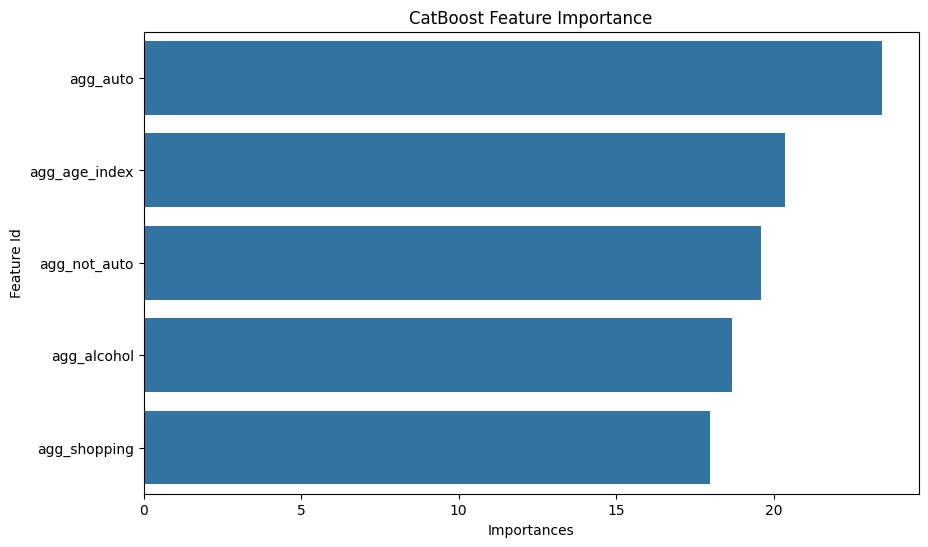

In [8]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import seaborn as sns


X = new_features
y = casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, stratify=y, random_state=123)

model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.0001,
    depth=6,
    eval_metric='AUC',
    verbose=200
)

model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=500,
    use_best_model=True
)

importances = model.get_feature_importance(prettified=True)
print('\nВажность признаков:')
print(importances)

importances = model.get_feature_importance(prettified=True)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importances', y='Feature Id', data=importances)
plt.title('CatBoost Feature Importance')
plt.show()

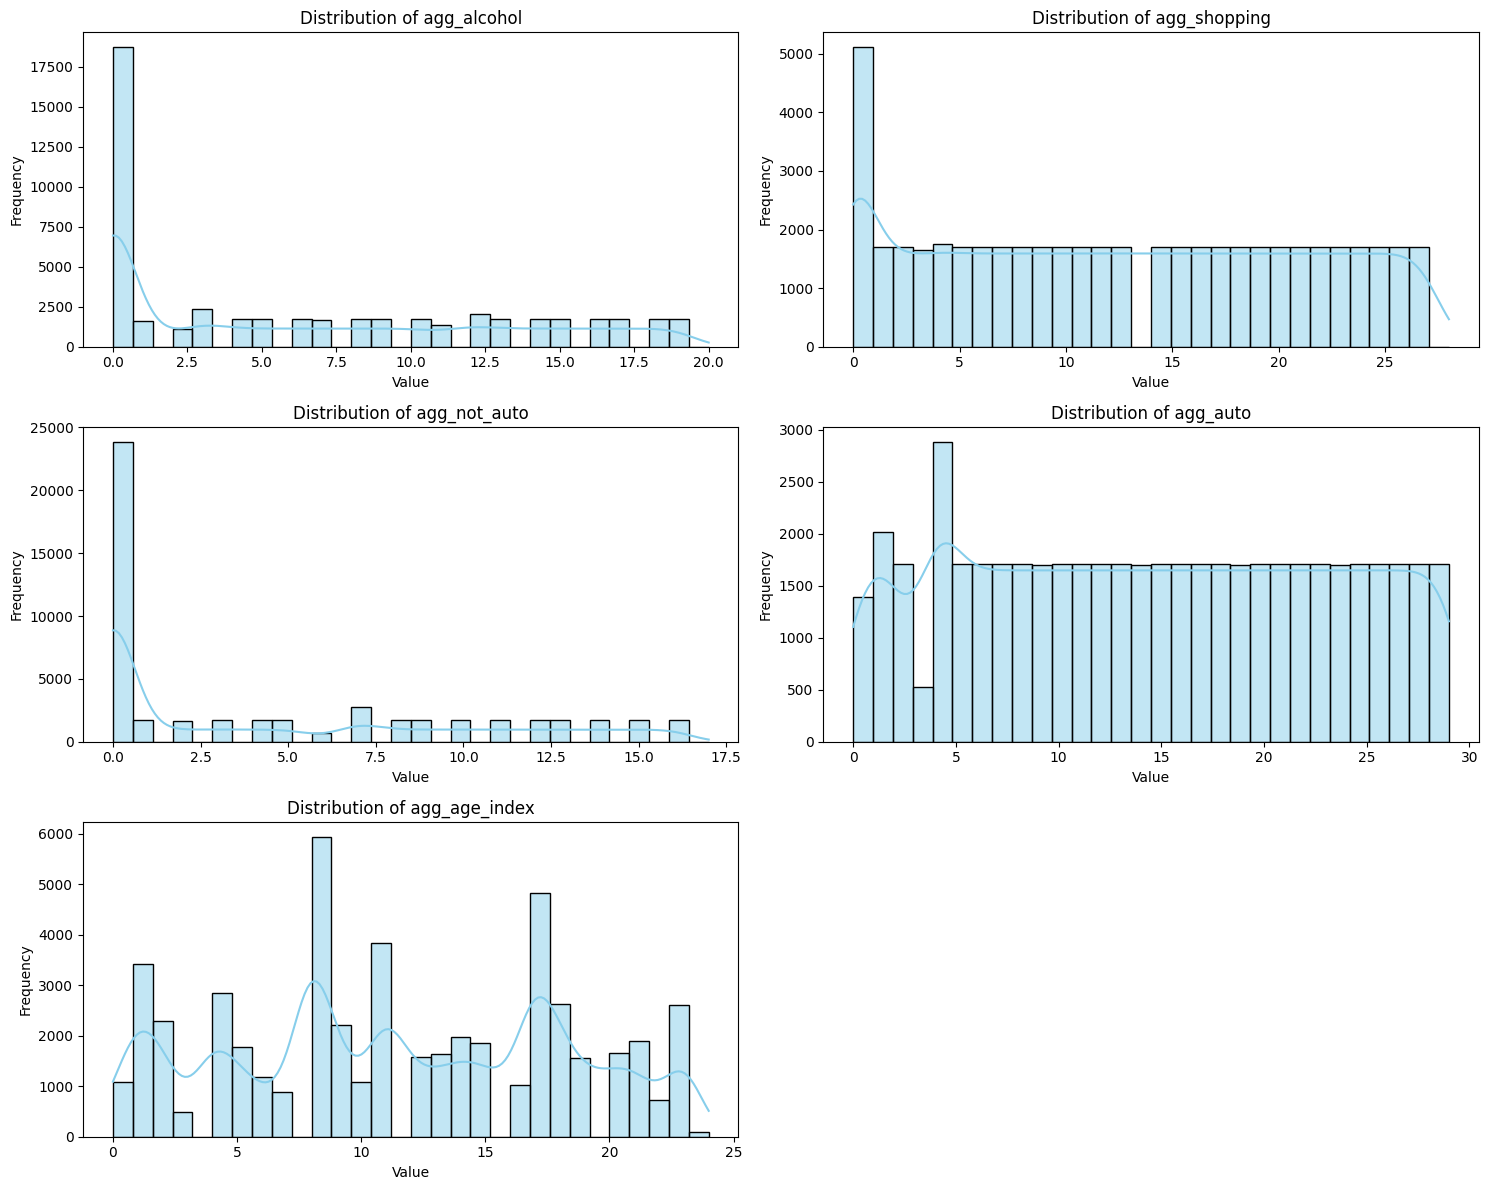

In [9]:
new_features.describe()
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Список признаков для визуализации (старый подход)
features = [
    'agg_alcohol', 'agg_shopping', 'agg_not_auto', 'agg_auto',
    'agg_age_index'
]

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(new_features[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## график

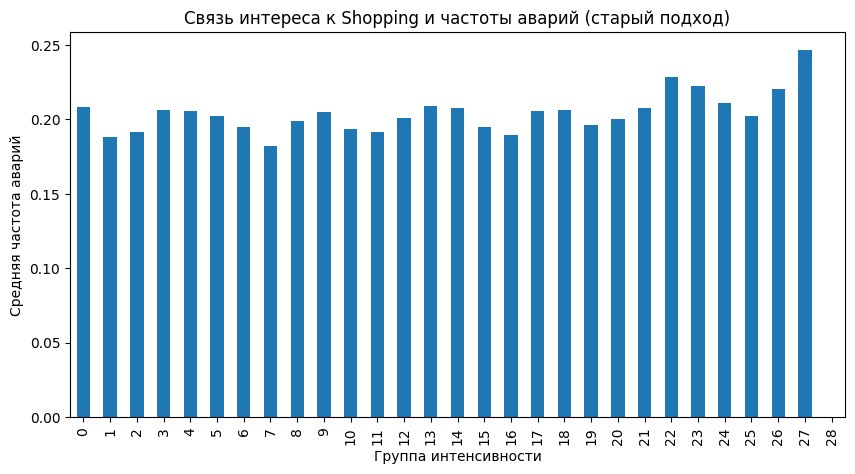

In [10]:
import matplotlib.pyplot as plt

# 1. Объединяем ваши новые признаки с данными по авариям
check_df = pd.concat([new_features, casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']], axis=1)

# 2. Считаем среднюю аварийность для каждой группы алкоголя (старый подход)
analysis = check_df.groupby('agg_shopping')['BINARY_CLAIMS_PART_DAM_COUNT'].mean()

# 3. Строим график
analysis.plot(kind='bar', figsize=(10, 5))
plt.title('Связь интереса к Shopping и частоты аварий (старый подход)')
plt.ylabel('Средняя частота аварий')
plt.xlabel('Группа интенсивности')
plt.show()


# Линейная комбинация + монотонные группы
Ниже оставлен альтернативный подход для EMBLEM/WTW: строим линейный скор по TAG, затем делаем монотонные группы по частоте claims через PAV.


In [11]:
# --- Универсальный монотонный раннер для любых групп TAG ---
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression


def _pav_blocks(rates, weights):
    """Pooled Adjacent Violators: объединяет соседние бины до неубывающего тренда."""
    blocks = [
        {'start': i, 'end': i, 'rate': float(r), 'w': float(w)}
        for i, (r, w) in enumerate(zip(rates, weights))
    ]

    i = 0
    while i < len(blocks) - 1:
        if blocks[i]['rate'] > blocks[i + 1]['rate']:
            left, right = blocks[i], blocks[i + 1]
            total_w = left['w'] + right['w']
            merged_rate = (left['rate'] * left['w'] + right['rate'] * right['w']) / total_w
            blocks[i] = {
                'start': left['start'],
                'end': right['end'],
                'rate': merged_rate,
                'w': total_w
            }
            del blocks[i + 1]
            if i > 0:
                i -= 1
        else:
            i += 1

    return blocks


class MonotonicLinearGrouper:
    """Линейный скор по TAG + PAV-схлопывание в неубывающий тренд частоты claims."""
    def __init__(self, n_groups=30, C=0.35, random_state=42):
        self.n_groups = n_groups
        self.C = C
        self.random_state = random_state

        self.columns_ = None
        self.weights_ = None
        self.prebin_edges_ = None
        self.prebin_to_group_ = None
        self.group_stats_ = None
        self.n_groups_actual_ = None

    def fit(self, df, cols, y, feature_name='feature'):
        selected_cols = [c for c in cols if c in df.columns]
        if not selected_cols:
            raise ValueError(f"Не найдено ни одного TAG для '{feature_name}' в данных.")

        X = df[selected_cols].fillna(0).astype(float)
        y = pd.Series(y, index=df.index).astype(int)

        non_const = X.nunique(dropna=False)
        self.columns_ = non_const[non_const > 1].index.tolist()
        if not self.columns_:
            raise ValueError(f"Все TAG для '{feature_name}' оказались константными.")

        X = X[self.columns_]

        logreg = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=self.C,
            max_iter=6000,
            random_state=self.random_state,
            n_jobs=-1
        )
        logreg.fit(X, y)

        weights = pd.Series(logreg.coef_.ravel(), index=self.columns_)
        weights = weights.clip(lower=0)
        if (weights > 0).sum() == 0:
            weights = pd.Series(np.abs(logreg.coef_.ravel()), index=self.columns_)
        self.weights_ = weights

        score = X.dot(self.weights_)

        quantiles = np.linspace(0, 1, self.n_groups + 1)
        edges = np.quantile(score, quantiles)
        edges = np.unique(edges)
        if len(edges) < 2:
            edges = np.array([score.min(), score.max() + 1e-9])

        self.prebin_edges_ = edges
        prebin = np.digitize(score, self.prebin_edges_[1:-1], right=True)

        pre_stats = (
            pd.DataFrame({'prebin': prebin, 'target': y.values})
            .groupby('prebin', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
        )

        blocks = _pav_blocks(pre_stats['mean'].values, pre_stats['count'].values)

        prebin_to_group = {}
        for group_id, block in enumerate(blocks):
            for b in range(block['start'], block['end'] + 1):
                prebin_to_group[b] = group_id
        self.prebin_to_group_ = prebin_to_group

        groups = pd.Series(prebin, index=df.index).map(self.prebin_to_group_).astype(int)

        self.group_stats_ = (
            pd.DataFrame({'group': groups, 'target': y.values})
            .groupby('group', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
            .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
        )
        self.n_groups_actual_ = int(self.group_stats_.shape[0])

        return self

    def transform(self, df):
        if self.columns_ is None:
            raise ValueError("Сначала вызовите fit().")

        X = df.reindex(columns=self.columns_, fill_value=0).fillna(0).astype(float)
        score = X.dot(self.weights_)
        prebin = np.digitize(score, self.prebin_edges_[1:-1], right=True)
        groups = pd.Series(prebin, index=df.index).map(self.prebin_to_group_).astype(int)
        return groups, score


def fit_monotonic_candidates(df, feature_cols, y, candidate_groups=(20, 25, 30), C=0.35, random_state=42, feature_name='feature', verbose=True):
    candidate_groupers = {}
    summary_rows = []

    for n in candidate_groups:
        g = MonotonicLinearGrouper(n_groups=n, C=C, random_state=random_state)
        g.fit(df, feature_cols, y, feature_name=feature_name)
        candidate_groupers[n] = g

        monotonic_ok = bool(np.all(np.diff(g.group_stats_['claim_rate'].values) >= -1e-12))
        summary_rows.append({
            'feature': feature_name,
            'requested_groups': int(n),
            'actual_after_pav': int(g.n_groups_actual_),
            'monotonic_non_decreasing': monotonic_ok
        })

        if verbose:
            print(f"\n=== {feature_name}: requested={n}, actual_after_PAV={g.n_groups_actual_}, monotonic={monotonic_ok} ===")
            print(g.group_stats_)

    summary_df = pd.DataFrame(summary_rows).sort_values('requested_groups').reset_index(drop=True)
    return candidate_groupers, summary_df


def apply_monotonic_feature(df, out_df, output_col, feature_cols, y, selected_groups=30, candidate_groups=(20, 25, 30), C=0.35, random_state=42, feature_name='feature', verbose=True):
    candidate_groupers, summary_df = fit_monotonic_candidates(
        df=df,
        feature_cols=feature_cols,
        y=y,
        candidate_groups=candidate_groups,
        C=C,
        random_state=random_state,
        feature_name=feature_name,
        verbose=verbose
    )

    if selected_groups in candidate_groupers:
        selected_grouper = candidate_groupers[selected_groups]
    else:
        selected_grouper = MonotonicLinearGrouper(n_groups=selected_groups, C=C, random_state=random_state)
        selected_grouper.fit(df, feature_cols, y, feature_name=feature_name)

    groups, score = selected_grouper.transform(df)
    out_df[output_col] = groups
    return selected_grouper, candidate_groupers, summary_df, score


# Прогоняем этим подходом сразу несколько групп
CANDIDATE_GROUPS = [20, 25, 30]
SELECTED_GROUPS = 30

feature_jobs = [
    {
        'feature_name': 'shopping',
        'output_col': 'agg_shopping_monotonic',
        'feature_cols': shopping_features_list,
        'selected_groups': SELECTED_GROUPS
    }
]

new_features_monotonic = new_features.copy()
monotonic_groupers = {}
candidate_groupers_by_feature = {}
scores_by_feature = {}
summary_frames = []

for job in feature_jobs:
    selected_grouper_tmp, candidate_groupers_tmp, summary_tmp, score_tmp = apply_monotonic_feature(
        df=casco_hashtags_full,
        out_df=new_features_monotonic,
        output_col=job['output_col'],
        feature_cols=job['feature_cols'],
        y=casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT'],
        selected_groups=job['selected_groups'],
        candidate_groups=CANDIDATE_GROUPS,
        C=0.35,
        random_state=42,
        feature_name=job['feature_name'],
        verbose=False
    )

    monotonic_groupers[job['feature_name']] = selected_grouper_tmp
    candidate_groupers_by_feature[job['feature_name']] = candidate_groupers_tmp
    scores_by_feature[job['feature_name']] = score_tmp

    summary_tmp = summary_tmp.copy()
    summary_tmp.insert(1, 'output_col', job['output_col'])
    summary_frames.append(summary_tmp)

monotonic_summary = pd.concat(summary_frames, ignore_index=True)
print('Summary by candidates:')
print(monotonic_summary.to_string(index=False))

# Для анализа auto
selected_grouper = monotonic_groupers['shopping']
group_score = scores_by_feature['shopping']

GROUP_SCORE_NORM_COL = 'agg_shopping_monotonic_score_norm'
GROUP_SCORE_BINARY_COL = 'agg_shopping_monotonic_score_bin'
GROUP_SCORE_BINARY_THRESHOLD = 0.5
group_score_norm = (group_score - group_score.min()) / (group_score.max() - group_score.min() + 1e-12)
new_features_monotonic[GROUP_SCORE_NORM_COL] = group_score_norm
new_features_monotonic[GROUP_SCORE_BINARY_COL] = (group_score_norm >= GROUP_SCORE_BINARY_THRESHOLD).astype(int)
group_score_csv_path = CSV_DIR / 'agg_shopping_monotonic_score_with_binary.csv'
pd.DataFrame(
    {
        GROUP_SCORE_NORM_COL: new_features_monotonic[GROUP_SCORE_NORM_COL],
        GROUP_SCORE_BINARY_COL: new_features_monotonic[GROUP_SCORE_BINARY_COL]
    },
    index=new_features_monotonic.index
).to_csv(
    group_score_csv_path,
    index=True,
    encoding='utf-8-sig'
)
print(f"Сохранен shopping score (continuous + binary): {group_score_csv_path}")

print("\nTop-10 shopping TAG weights:")
print(selected_grouper.weights_.sort_values(ascending=False).head(10))


Summary by candidates:
 feature             output_col  requested_groups  actual_after_pav  monotonic_non_decreasing
shopping agg_shopping_monotonic                20                 8                      True
shopping agg_shopping_monotonic                25                10                      True
shopping agg_shopping_monotonic                30                10                      True
Сохранен shopping score (continuous + binary): artifacts\csv\agg_shopping_monotonic_score_with_binary.csv

Top-10 shopping TAG weights:
TAG_20158    0.206923
TAG_22019    0.173984
TAG_20937    0.167921
TAG_12952    0.151851
TAG_20178    0.129726
TAG_21144    0.127334
TAG_12610    0.117432
TAG_21998    0.108105
TAG_21162    0.098347
TAG_27180    0.087898
dtype: float64


                        claim_rate  objects
agg_shopping_monotonic                     
0                         0.192736    20458
1                         0.192962     3410
2                         0.195448     8524
3                         0.204106     1705
4                         0.208566     3409
5                         0.214467     5115
6                         0.224993     3409
7                         0.238123     1705
8                         0.250440     1705
9                         0.256305     1705

Группы неубывающие по частоте: True


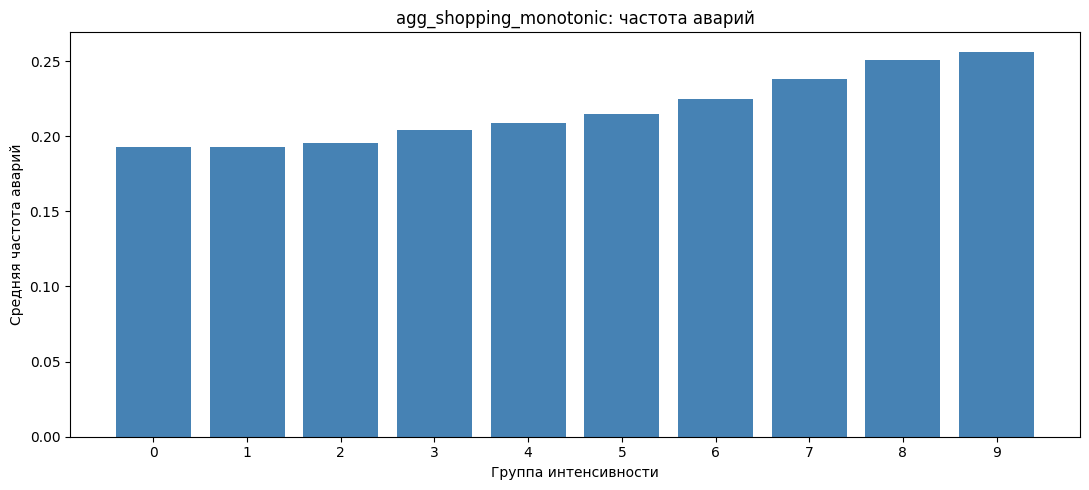

In [12]:
# Проверка монотонного тренда для agg_shopping_monotonic
import matplotlib.pyplot as plt
import numpy as np

check_df_monotonic = pd.concat([
    new_features_monotonic,
    casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']
], axis=1)

analysis_monotonic = (
    check_df_monotonic.groupby('agg_shopping_monotonic', as_index=True)['BINARY_CLAIMS_PART_DAM_COUNT']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
    .sort_index()
)

print(analysis_monotonic)
monotonic_non_decreasing = bool(np.all(np.diff(analysis_monotonic['claim_rate'].values) >= -1e-12))
print(f"\nГруппы неубывающие по частоте: {monotonic_non_decreasing}")

plt.figure(figsize=(11, 5))
plt.bar(analysis_monotonic.index.astype(str), analysis_monotonic['claim_rate'], color='steelblue')
plt.title('agg_shopping_monotonic: частота аварий')
plt.ylabel('Средняя частота аварий')
plt.xlabel('Группа интенсивности')
plt.tight_layout()
plt.show()


In [13]:
# --- Какие TAG зашли в новую agg_shopping_monotonic ---
# Требуется, чтобы была выполнена ячейка с selected_grouper.fit(...)

calc_tags = pd.Index(selected_grouper.columns_, name='TAG')

used = (
    selected_grouper.weights_
    .rename('weight')
    .reset_index()
    .rename(columns={'index': 'TAG'})
    .query('weight > 0')
    .sort_values('weight', ascending=False)
)

tag_map = tags_descriptions[['TAG', 'TAG_NAME fin SBS']].drop_duplicates()
used = used.merge(tag_map, on='TAG', how='left')

print(f'Участвовали в расчете: {len(calc_tags)} TAG')
print(f'С ненулевым весом: {len(used)} TAG')
print('\nТоп-30 TAG по весу:')
print(used[['TAG', 'TAG_NAME fin SBS', 'weight']].head(30).to_string(index=False))

# Полный список можно сохранить для передачи в EMBLEM/WTW
used_csv_path = CSV_DIR / 'agg_shopping_monotonic_used_tags.csv'
used.to_csv(used_csv_path, index=False, encoding='utf-8-sig')
print(f"\nСохранено: {used_csv_path}")

Участвовали в расчете: 89 TAG
С ненулевым весом: 51 TAG

Топ-30 TAG по весу:
      TAG                                                  TAG_NAME fin SBS   weight
TAG_20158                           Склонен совершать покупки в АЗС Газпром 0.206923
TAG_22019                            Склонен к покупке запчастей в Exist.ru 0.173984
TAG_20937          Склонен к покупке в магазине детских товаров Rich Family 0.167921
TAG_12952           Склонен к покупке продуктов в супермаркете Азбука Вкуса 0.151851
TAG_20178                       Склонен совершать покупки в Нефтьмагистраль 0.129726
TAG_21144           Склонен к покупкам в магазинах товаров для дома ПорядОк 0.127334
TAG_12610                     Склонен к покупкам в магазине одежды Reserved 0.117432
TAG_21998                             Привычка покупать запчасти в Авторусь 0.108105
TAG_21162    Склонен к покупкам в магазинах товаров для ремонта Строймаркет 0.098347
TAG_27180                      Склонен совершать покупки в аптеках ГорЗдр

применение подхода для другой группы

In [14]:
selected_group_feature, _, group_summary, group_score = apply_monotonic_feature(
    df=casco_hashtags_full,
    out_df=new_features_monotonic,              # сюда запишется новая переменная
    output_col='agg_shopping_monotonic',        # имя новой колонки
    feature_cols=shopping_features_list,        # список TAG этой группы
    y=casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT'],
    selected_groups=25,                         # 20/25/30
    candidate_groups=[20, 25, 30],
    feature_name='shopping',
    verbose=True
)

print(group_summary)
print(selected_group_feature.group_stats_)


=== shopping: requested=20, actual_after_PAV=8, monotonic=True ===
       claim_rate  objects
group                     
0        0.192736    20458
1        0.194740    10229
2        0.195151     2557
3        0.210166     5115
4        0.216269     5114
5        0.224873     2557
6        0.238952     2557
7        0.257623     2558

=== shopping: requested=25, actual_after_PAV=10, monotonic=True ===
       claim_rate  objects
group                     
0        0.192736    20458
1        0.194740    10229
2        0.197458     2046
3        0.204401     2045
4        0.204790     2046
5        0.215741     6137
6        0.217986     2046
7        0.233627     2046
8        0.244868     2046
9        0.261486     2046

=== shopping: requested=30, actual_after_PAV=10, monotonic=True ===
       claim_rate  objects
group                     
0        0.192736    20458
1        0.192962     3410
2        0.195448     8524
3        0.204106     1705
4        0.208566     3409
5        0.

## график

                        claim_rate  objects
agg_shopping_monotonic                     
0                         0.192736    20458
1                         0.194740    10229
2                         0.197458     2046
3                         0.204401     2045
4                         0.204790     2046
5                         0.215741     6137
6                         0.217986     2046
7                         0.233627     2046
8                         0.244868     2046
9                         0.261486     2046

Группы неубывающие по частоте: True


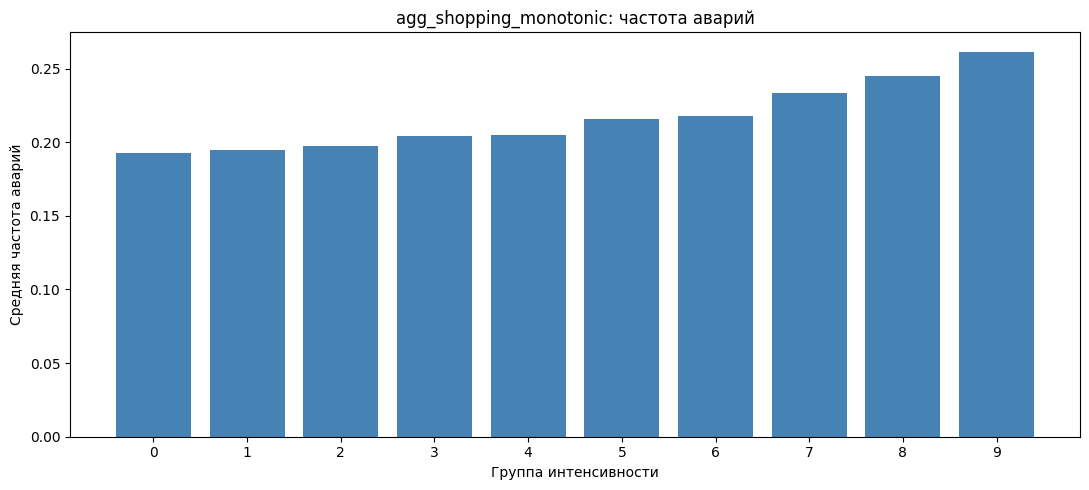

In [15]:
# Проверка монотонного тренда для agg_shopping_monotonic
import matplotlib.pyplot as plt
import numpy as np

check_df_monotonic = pd.concat([
    new_features_monotonic,
    casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']
], axis=1)

analysis_monotonic = (
    check_df_monotonic.groupby('agg_shopping_monotonic', as_index=True)['BINARY_CLAIMS_PART_DAM_COUNT']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
    .sort_index()
)

print(analysis_monotonic)
monotonic_non_decreasing = bool(np.all(np.diff(analysis_monotonic['claim_rate'].values) >= -1e-12))
print(f"\nГруппы неубывающие по частоте: {monotonic_non_decreasing}")

plt.figure(figsize=(11, 5))
plt.bar(analysis_monotonic.index.astype(str), analysis_monotonic['claim_rate'], color='steelblue')
plt.title('agg_shopping_monotonic: частота аварий')
plt.ylabel('Средняя частота аварий')
plt.xlabel('Группа интенсивности')
plt.tight_layout()
plt.show()


# Линейная комбинация без весов + квантильные группы (схлопывание как в AggregatedHashtagsProcessor)
Подход: суммируем выбранные TAG без весов, нормируем MinMax, биним квантилями и проверяем тренд как восходящий, так и нисходящий.


In [16]:
def _detect_monotonic_direction(rates, tol=1e-12):
    rates = np.asarray(rates, dtype=float)
    if rates.size <= 1:
        return 'flat', True, True

    diffs = np.diff(rates)
    non_decreasing = bool(np.all(diffs >= -tol))
    non_increasing = bool(np.all(diffs <= tol))

    if non_decreasing and non_increasing:
        direction = 'flat'
    elif non_decreasing:
        direction = 'up'
    elif non_increasing:
        direction = 'down'
    else:
        direction = None

    return direction, non_decreasing, non_increasing


class UnweightedQuantileTrendGrouper:
    """
    Линейная комбинация TAG без весов:
        score = sum(TAG_i)

    Схлопывание делается так же, как в AggregatedHashtagsProcessor:
        1) MinMaxScaler
        2) quantile-binning
        3) np.digitize + clip

    После бининга проверяем тренд claim_rate на:
        - неубывание (up)
        - невозрастание (down)
    """
    def __init__(self, n_groups=30):
        self.n_groups = int(n_groups)
        self.columns_ = None
        self.scaler_ = None
        self.bins_ = None
        self.group_stats_ = None
        self.n_groups_actual_ = None
        self.monotonic_non_decreasing_ = None
        self.monotonic_non_increasing_ = None
        self.trend_direction_ = None

    def _safe_column_selection(self, df, cols):
        existing_cols = [col for col in cols if col in df.columns]
        missing_cols = sorted(set(cols) - set(existing_cols))
        if missing_cols:
            print(f"Внимание: следующие TAG не найдены: {missing_cols}")
        return existing_cols

    def fit(self, df, cols, y, feature_name='feature'):
        if self.n_groups < 2:
            raise ValueError('n_groups должен быть >= 2')

        selected_cols = self._safe_column_selection(df, cols)
        if not selected_cols:
            raise ValueError(f"Не найдено ни одного TAG для '{feature_name}' в данных.")

        X = df[selected_cols].fillna(0).astype(float)
        non_const = X.nunique(dropna=False)
        self.columns_ = non_const[non_const > 1].index.tolist()
        if not self.columns_:
            raise ValueError(f"Все TAG для '{feature_name}' оказались константными.")

        score = X[self.columns_].sum(axis=1, min_count=1).fillna(0)

        self.scaler_ = MinMaxScaler()
        score_norm = self.scaler_.fit_transform(score.values.reshape(-1, 1)).flatten()

        quantiles = np.linspace(0, 1, self.n_groups + 1)
        bins = np.quantile(score_norm, quantiles)
        bins = np.unique(bins)
        if len(bins) < 2:
            bins = np.array([0.0, 1.0])
        self.bins_ = bins

        groups = np.digitize(score_norm, self.bins_) - 1
        groups = np.clip(groups, 0, self.n_groups - 1)

        y_series = pd.Series(y, index=df.index).astype(float)
        self.group_stats_ = (
            pd.DataFrame({'group': groups, 'target': y_series.values})
            .groupby('group', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
            .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
        )
        self.n_groups_actual_ = int(self.group_stats_.shape[0])

        self.trend_direction_, self.monotonic_non_decreasing_, self.monotonic_non_increasing_ = _detect_monotonic_direction(
            self.group_stats_['claim_rate'].values
        )

        return self

    def transform(self, df):
        if self.columns_ is None or self.scaler_ is None or self.bins_ is None:
            raise ValueError('Сначала вызовите fit().')

        X = df.reindex(columns=self.columns_, fill_value=0).fillna(0).astype(float)
        score = X.sum(axis=1, min_count=1).fillna(0)
        score_norm = self.scaler_.transform(score.values.reshape(-1, 1)).flatten()

        groups = np.digitize(score_norm, self.bins_) - 1
        groups = np.clip(groups, 0, self.n_groups - 1)

        return pd.Series(groups, index=df.index, name='group').astype(int), score


def fit_unweighted_trend_candidates(
    df,
    feature_cols,
    y,
    candidate_groups=(20, 25, 30),
    candidate_tag_counts=None,
    feature_name='feature',
    min_groups_for_trend=3,
    verbose=True
):
    existing_cols = [c for c in feature_cols if c in df.columns]
    if not existing_cols:
        raise ValueError(f"Не найдено ни одного TAG для '{feature_name}' в данных.")

    if candidate_tag_counts is None:
        tag_counts = [len(existing_cols)]
    else:
        tag_counts = sorted({int(k) for k in candidate_tag_counts if int(k) > 0})
        tag_counts = [k for k in tag_counts if k <= len(existing_cols)]
        if len(existing_cols) not in tag_counts:
            tag_counts.append(len(existing_cols))
        if not tag_counts:
            raise ValueError('После фильтрации candidate_tag_counts не осталось валидных значений.')

    summary_rows = []
    candidate_groupers = {}

    for tag_count in tag_counts:
        cols_subset = existing_cols[:tag_count]

        for n in candidate_groups:
            g = UnweightedQuantileTrendGrouper(n_groups=n)
            g.fit(df=df, cols=cols_subset, y=y, feature_name=feature_name)

            trend_found = (
                g.trend_direction_ in ('up', 'down')
                and g.n_groups_actual_ >= int(min_groups_for_trend)
            )

            key = (int(tag_count), int(n))
            candidate_groupers[key] = g

            summary_rows.append({
                'feature': feature_name,
                'tag_count': int(tag_count),
                'requested_groups': int(n),
                'actual_groups': int(g.n_groups_actual_),
                'trend_direction': g.trend_direction_,
                'monotonic_non_decreasing': bool(g.monotonic_non_decreasing_),
                'monotonic_non_increasing': bool(g.monotonic_non_increasing_),
                'trend_found': bool(trend_found)
            })

            if verbose:
                print(
                    f"\n=== {feature_name}: tags={tag_count}, requested_groups={n}, "
                    f"actual_groups={g.n_groups_actual_}, trend={g.trend_direction_}, trend_found={trend_found} ==="
                )
                print(g.group_stats_)

    summary_df = (
        pd.DataFrame(summary_rows)
        .sort_values(['tag_count', 'requested_groups'])
        .reset_index(drop=True)
    )

    return candidate_groupers, summary_df


def apply_unweighted_trend_feature(
    df,
    out_df,
    output_col,
    feature_cols,
    y,
    selected_groups=30,
    selected_tag_count=None,
    candidate_groups=(20, 25, 30),
    candidate_tag_counts=None,
    feature_name='feature',
    min_groups_for_trend=3,
    verbose=True
):
    existing_cols = [c for c in feature_cols if c in df.columns]
    if not existing_cols:
        raise ValueError(f"Не найдено ни одного TAG для '{feature_name}' в данных.")

    if selected_tag_count is None:
        selected_tag_count = len(existing_cols)

    candidate_groupers, summary_df = fit_unweighted_trend_candidates(
        df=df,
        feature_cols=feature_cols,
        y=y,
        candidate_groups=candidate_groups,
        candidate_tag_counts=candidate_tag_counts,
        feature_name=feature_name,
        min_groups_for_trend=min_groups_for_trend,
        verbose=verbose
    )

    selected_key = (int(selected_tag_count), int(selected_groups))
    selected_grouper = candidate_groupers.get(selected_key)

    selected_ok = (
        selected_grouper is not None
        and selected_grouper.trend_direction_ in ('up', 'down')
        and selected_grouper.n_groups_actual_ >= int(min_groups_for_trend)
    )

    if not selected_ok:
        ok_df = summary_df[summary_df['trend_found']].copy()
        if ok_df.empty:
            print(
                f"Для '{feature_name}' данный метод не позволяет найти в этой группе "
                f"набор подходящих тегов, который дает восходящий или нисходящий тренд."
            )
            return None, candidate_groupers, summary_df, None

        ok_df['tag_distance'] = (ok_df['tag_count'] - int(selected_tag_count)).abs()
        ok_df['group_distance'] = (ok_df['requested_groups'] - int(selected_groups)).abs()
        ok_df = ok_df.sort_values(
            ['tag_distance', 'group_distance', 'actual_groups'],
            ascending=[True, True, False]
        )
        best = ok_df.iloc[0]
        selected_key = (int(best['tag_count']), int(best['requested_groups']))
        selected_grouper = candidate_groupers[selected_key]

    groups, score = selected_grouper.transform(df)
    out_df[output_col] = groups

    print(
        f"Выбран вариант для '{feature_name}': tags={len(selected_grouper.columns_)}, "
        f"requested_groups={selected_grouper.n_groups}, actual_groups={selected_grouper.n_groups_actual_}, "
        f"trend={selected_grouper.trend_direction_}"
    )

    return selected_grouper, candidate_groupers, summary_df, score


## график

In [17]:
# --- Пример: безвесовая линейная комбинация для любой группы TAG ---
CANDIDATE_GROUPS_UNWEIGHTED = [20, 25, 30]

existing_group_tags = [c for c in shopping_features_list if c in casco_hashtags_full.columns]
if not existing_group_tags:
    print('Не найдено ни одного TAG из shopping_features_list в текущем датафрейме.')
else:
    candidate_tag_counts_demo = sorted(set([
        min(6, len(existing_group_tags)),
        min(10, len(existing_group_tags)),
        len(existing_group_tags)
    ]))
    candidate_tag_counts_demo = [k for k in candidate_tag_counts_demo if k > 0]

    new_features_unweighted = new_features.copy()

    selected_unweighted, candidate_groupers_unweighted, summary_unweighted, unweighted_score = apply_unweighted_trend_feature(
        df=casco_hashtags_full,
        out_df=new_features_unweighted,
        output_col='agg_shopping_unweighted_trend',
        feature_cols=shopping_features_list,
        y=casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT'],
        selected_groups=25,
        selected_tag_count=len(existing_group_tags),
        candidate_groups=CANDIDATE_GROUPS_UNWEIGHTED,
        candidate_tag_counts=candidate_tag_counts_demo,
        feature_name='shopping_unweighted',
        min_groups_for_trend=3,
        verbose=False
    )

    print(summary_unweighted.to_string(index=False))

    if selected_unweighted is not None:
        check_df_unweighted = pd.concat([
            new_features_unweighted[['agg_shopping_unweighted_trend']],
            casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']
        ], axis=1)

        analysis_unweighted = (
            check_df_unweighted.groupby('agg_shopping_unweighted_trend', as_index=True)['BINARY_CLAIMS_PART_DAM_COUNT']
            .agg(['mean', 'count'])
            .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
            .sort_index()
        )

        trend_direction, monotonic_up, monotonic_down = _detect_monotonic_direction(
            analysis_unweighted['claim_rate'].values
        )
        trend_map = {
            'up': 'восходящий',
            'down': 'нисходящий',
            'flat': 'плоский',
            None: 'не монотонный'
        }

        print('\nАнализ выбранного варианта:')
        print(analysis_unweighted)
        print(f"\nНаправление тренда: {trend_map[trend_direction]}")
        print(f"Неубывающий: {monotonic_up}, невозрастающий: {monotonic_down}")

        plt.figure(figsize=(11, 5))
        plt.bar(analysis_unweighted.index.astype(str), analysis_unweighted['claim_rate'], color='steelblue')
        plt.title('agg_shopping_unweighted_trend: частота аварий')
        plt.ylabel('Средняя частота аварий')
        plt.xlabel('Группа интенсивности')
        plt.tight_layout()
        plt.show()


Для 'shopping_unweighted' данный метод не позволяет найти в этой группе набор подходящих тегов, который дает восходящий или нисходящий тренд.
            feature  tag_count  requested_groups  actual_groups trend_direction  monotonic_non_decreasing  monotonic_non_increasing  trend_found
shopping_unweighted          6                20             16            None                     False                     False        False
shopping_unweighted          6                25             18            None                     False                     False        False
shopping_unweighted          6                30             22            None                     False                     False        False
shopping_unweighted         10                20             15            None                     False                     False        False
shopping_unweighted         10                25             20            None                     False                     False  

# Линейная комбинация + strict equal-count квантили (поиск комбинации TAG)

Идея: целочисленные веса + строго равные по размеру группы. Дополнительно ищем такую комбинацию TAG и число групп, чтобы получить динамику (восходящую или нисходящую), сохраняя определение квантильного разбиения.


In [18]:
class IntegerMonotonicLinearGrouper:

    """
    Линейный скор по TAG с целочисленными весами + strict equal-count binning.

    grouping_strategy:
      - 'strict_equal_count' (рекомендуется для WTW/Emblem):
          группы строятся одинакового размера (если requested_groups не делит N,
          подбирается ближайший делитель N).
      - 'quantile': обычный quantile-binning (equal-frequency, но возможны перекосы из-за ties).

    use_pav:
      - False: сохраняем equal-count (для strict стратегии)
      - True: включаем PAV-схлопывание (монотонность, но группы перестают быть равными)
    """

    def __init__(
        self,
        n_groups=30,
        C=0.35,
        max_int_weight=10,
        min_nonzero_weight=1,
        random_state=42,
        use_pav=False,
        grouping_strategy='strict_equal_count',
        enforce_exact_equal=True
    ):
        self.n_groups = int(n_groups)
        self.C = float(C)
        self.max_int_weight = int(max_int_weight)
        self.min_nonzero_weight = int(min_nonzero_weight)
        self.random_state = random_state
        self.use_pav = bool(use_pav)
        self.grouping_strategy = str(grouping_strategy)
        self.enforce_exact_equal = bool(enforce_exact_equal)

        self.columns_ = None
        self.weights_raw_ = None
        self.weights_ = None
        self.prebin_edges_ = None
        self.prebin_to_group_ = None
        self.prebin_stats_ = None
        self.group_stats_ = None
        self.n_groups_actual_ = None
        self.n_groups_requested_ = int(n_groups)
        self.n_groups_effective_ = int(n_groups)
        self.equal_group_size_ = None

    def _build_integer_weights(self, raw_weights):
        w = raw_weights.copy().clip(lower=0)
        if (w > 0).sum() == 0:
            w = raw_weights.abs()
        if (w > 0).sum() == 0:
            w = pd.Series(1.0, index=raw_weights.index)

        w_norm = w / w.max()
        w_int = (w_norm * self.max_int_weight).round().astype(int)
        mask_nonzero = w > 0
        w_int.loc[mask_nonzero & (w_int == 0)] = self.min_nonzero_weight
        w_int = w_int.clip(lower=0, upper=self.max_int_weight)
        return w_int

    def _nearest_divisor(self, n, target):
        # Ищем делитель n (>=3), ближайший к target, но не выше target.
        divisors = [g for g in range(3, n + 1) if n % g == 0]
        if not divisors:
            return None

        not_above = [g for g in divisors if g <= target]
        if not_above:
            # Самый близкий к target снизу.
            return max(not_above)

        # Если ниже target делителей нет, берем минимально возможный.
        return min(divisors)

    def _assign_groups_strict(self, score, n_groups):
        s = pd.Series(score).astype(float)
        n = len(s)
        g = int(max(3, min(int(n_groups), n)))

        # Детерминированный порядок: score, затем индекс
        idx_as_str = s.index.astype(str).to_numpy()
        order = np.lexsort((idx_as_str, s.to_numpy()))

        labels = np.empty(n, dtype=int)
        per_group = n // g
        start = 0
        for k in range(g):
            end = start + per_group
            labels[order[start:end]] = k
            start = end

        return pd.Series(labels, index=s.index, dtype=int)

    def fit(self, df, cols, y, feature_name='feature'):
        if self.n_groups < 3:
            raise ValueError('n_groups должен быть >= 3')
        if self.max_int_weight < 1:
            raise ValueError('max_int_weight должен быть >= 1')
        if self.grouping_strategy not in ('strict_equal_count', 'quantile'):
            raise ValueError("grouping_strategy должен быть 'strict_equal_count' или 'quantile'")
        if self.grouping_strategy == 'strict_equal_count' and self.use_pav:
            raise ValueError("Для strict_equal_count use_pav=True противоречит цели равных групп")

        selected_cols = [c for c in cols if c in df.columns]
        if not selected_cols:
            raise ValueError(f"Не найдено ни одного TAG для '{feature_name}' в данных.")

        X_full = df[selected_cols].fillna(0).astype(float)
        y = pd.Series(y, index=df.index).astype(int)

        non_const = X_full.nunique(dropna=False)
        model_cols = non_const[non_const > 1].index.tolist()
        if not model_cols:
            raise ValueError(f"Все TAG для '{feature_name}' оказались константными.")

        X_model = X_full[model_cols]
        logreg = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=self.C,
            max_iter=6000,
            random_state=self.random_state,
            n_jobs=-1
        )
        logreg.fit(X_model, y)

        self.weights_raw_ = pd.Series(logreg.coef_.ravel(), index=model_cols)
        weights_int_all = self._build_integer_weights(self.weights_raw_)
        weights_int_all = weights_int_all[weights_int_all > 0]
        if weights_int_all.empty:
            weights_int_all = pd.Series(1, index=model_cols, dtype=int)

        self.columns_ = weights_int_all.index.tolist()
        self.weights_ = weights_int_all.astype(int)

        X = X_full[self.columns_]
        score = X.dot(self.weights_)

        n_obs = len(score)
        self.n_groups_requested_ = int(self.n_groups)
        self.n_groups_effective_ = int(self.n_groups)

        if self.grouping_strategy == 'strict_equal_count':
            if self.enforce_exact_equal and (n_obs % self.n_groups_effective_ != 0):
                adjusted = self._nearest_divisor(n_obs, self.n_groups_effective_)
                if adjusted is None:
                    raise ValueError('Не удалось подобрать делитель для exact equal групп')
                self.n_groups_effective_ = int(adjusted)

            prebin_series = self._assign_groups_strict(score, self.n_groups_effective_)
            prebin = prebin_series.values
            self.prebin_edges_ = None
            self.prebin_to_group_ = {int(g): int(g) for g in sorted(prebin_series.unique())}
        else:
            quantiles = np.linspace(0, 1, self.n_groups_effective_ + 1)
            edges = np.quantile(score, quantiles)
            edges = np.unique(edges)
            if len(edges) < 2:
                edges = np.array([score.min(), score.max() + 1e-9])
            self.prebin_edges_ = edges
            prebin = np.digitize(score, self.prebin_edges_[1:-1], right=True)
            self.prebin_to_group_ = {int(g): int(g) for g in sorted(np.unique(prebin))}

        self.prebin_stats_ = (
            pd.DataFrame({'prebin': prebin, 'target': y.values})
            .groupby('prebin', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
        )

        groups = pd.Series(prebin, index=df.index).map(self.prebin_to_group_).astype(int)
        self.group_stats_ = (
            pd.DataFrame({'group': groups, 'target': y.values})
            .groupby('group', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
            .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
        )
        self.n_groups_actual_ = int(self.group_stats_.shape[0])
        self.equal_group_size_ = bool(self.group_stats_['objects'].nunique() == 1)
        return self

    def transform(self, df):
        if self.columns_ is None or self.weights_ is None:
            raise ValueError('Сначала вызовите fit().')

        X = df.reindex(columns=self.columns_, fill_value=0).fillna(0).astype(float)
        score = X.dot(self.weights_)

        if self.grouping_strategy == 'strict_equal_count':
            prebin = self._assign_groups_strict(score, self.n_groups_effective_).values
        else:
            prebin = np.digitize(score, self.prebin_edges_[1:-1], right=True)

        groups = pd.Series(prebin, index=df.index).map(self.prebin_to_group_).astype(int)
        return groups, score


def fit_monotonic_integer_candidates(
    df,
    feature_cols,
    y,
    candidate_groups=tuple(range(3, 31)),
    C=0.35,
    max_int_weight=10,
    min_nonzero_weight=1,
    random_state=42,
    feature_name='feature',
    verbose=True,
    use_pav=False,
    grouping_strategy='strict_equal_count',
    enforce_exact_equal=True
):
    candidate_groupers = {}
    summary_rows = []

    for n in candidate_groups:
        g = IntegerMonotonicLinearGrouper(
            n_groups=n,
            C=C,
            max_int_weight=max_int_weight,
            min_nonzero_weight=min_nonzero_weight,
            random_state=random_state,
            use_pav=use_pav,
            grouping_strategy=grouping_strategy,
            enforce_exact_equal=enforce_exact_equal
        )
        g.fit(df, feature_cols, y, feature_name=feature_name)
        candidate_groupers[int(n)] = g

        monotonic_ok = bool(np.all(np.diff(g.group_stats_['claim_rate'].values) >= -1e-12))
        summary_rows.append({
            'feature': feature_name,
            'requested_groups': int(n),
            'effective_groups': int(g.n_groups_effective_),
            'actual_groups': int(g.n_groups_actual_),
            'equal_group_size': bool(g.equal_group_size_),
            'monotonic_non_decreasing': monotonic_ok,
            'n_tags_with_weight': int((g.weights_ > 0).sum()),
            'max_integer_weight': int(g.weights_.max()),
            'grouping_strategy': grouping_strategy,
            'enforce_exact_equal': bool(enforce_exact_equal)
        })

        if verbose:
            print()
            print(
                f"=== {feature_name}: requested={n}, effective={g.n_groups_effective_}, actual={g.n_groups_actual_}, "
                f"equal_group_size={g.equal_group_size_}, monotonic={monotonic_ok}, tags={(g.weights_ > 0).sum()} ==="
            )
            print(g.group_stats_)

    summary_df = pd.DataFrame(summary_rows).sort_values('requested_groups').reset_index(drop=True)
    return candidate_groupers, summary_df


def apply_monotonic_integer_feature(
    df,
    out_df,
    output_col,
    feature_cols,
    y,
    selected_groups=30,
    candidate_groups=tuple(range(3, 31)),
    C=0.35,
    max_int_weight=10,
    min_nonzero_weight=1,
    random_state=42,
    feature_name='feature',
    verbose=True,
    use_pav=False,
    grouping_strategy='strict_equal_count',
    enforce_exact_equal=True
):
    candidate_groupers, summary_df = fit_monotonic_integer_candidates(
        df=df,
        feature_cols=feature_cols,
        y=y,
        candidate_groups=candidate_groups,
        C=C,
        max_int_weight=max_int_weight,
        min_nonzero_weight=min_nonzero_weight,
        random_state=random_state,
        feature_name=feature_name,
        verbose=verbose,
        use_pav=use_pav,
        grouping_strategy=grouping_strategy,
        enforce_exact_equal=enforce_exact_equal
    )

    if int(selected_groups) in candidate_groupers:
        selected_grouper = candidate_groupers[int(selected_groups)]
    else:
        selected_grouper = IntegerMonotonicLinearGrouper(
            n_groups=selected_groups,
            C=C,
            max_int_weight=max_int_weight,
            min_nonzero_weight=min_nonzero_weight,
            random_state=random_state,
            use_pav=use_pav,
            grouping_strategy=grouping_strategy,
            enforce_exact_equal=enforce_exact_equal
        )
        selected_grouper.fit(df, feature_cols, y, feature_name=feature_name)

    groups, score = selected_grouper.transform(df)
    out_df[output_col] = groups
    return selected_grouper, candidate_groupers, summary_df, score


def rank_tags_for_integer_model(df, feature_cols, y, C=0.35, max_int_weight=10, min_nonzero_weight=1, random_state=42):
    existing_cols = [c for c in feature_cols if c in df.columns]
    if not existing_cols:
        raise ValueError('Нет доступных TAG для ранжирования')

    # Используем технический фит для получения ранга TAG по integer weight.
    g_rank = IntegerMonotonicLinearGrouper(
        n_groups=10,
        C=C,
        max_int_weight=max_int_weight,
        min_nonzero_weight=min_nonzero_weight,
        random_state=random_state,
        use_pav=False,
        grouping_strategy='strict_equal_count',
        enforce_exact_equal=False
    )
    g_rank.fit(df, existing_cols, y, feature_name='rank_integer')
    ranked_weights = g_rank.weights_.sort_values(ascending=False)
    ranked_tags = ranked_weights.index.tolist()
    return ranked_tags, ranked_weights


def search_integer_equalcount_dynamic(
    df,
    feature_cols,
    y,
    candidate_groups=tuple(range(3, 31)),
    candidate_tag_counts=(8, 12, 16, 20, None),
    trend_mode='both',  # 'both', 'up', 'down', 'up_soft'
    soft_min_up_share=0.70,
    soft_min_slope=0.0,
    C=0.35,
    max_int_weight=10,
    min_nonzero_weight=1,
    random_state=42,
    verbose=True
):
    if trend_mode not in ('both', 'up', 'down', 'up_soft'):
        raise ValueError("trend_mode должен быть 'both'|'up'|'down'|'up_soft'")

    ranked_tags, ranked_weights = rank_tags_for_integer_model(
        df=df,
        feature_cols=feature_cols,
        y=y,
        C=C,
        max_int_weight=max_int_weight,
        min_nonzero_weight=min_nonzero_weight,
        random_state=random_state
    )

    if not ranked_tags:
        raise ValueError('После ранжирования не осталось TAG')

    tag_counts = []
    for k in candidate_tag_counts:
        if k is None:
            tag_counts.append(len(ranked_tags))
        else:
            tag_counts.append(int(k))
    tag_counts = sorted({k for k in tag_counts if 1 <= k <= len(ranked_tags)})
    if len(ranked_tags) not in tag_counts:
        tag_counts.append(len(ranked_tags))

    rows = []
    models = {}

    for k in tag_counts:
        subset = ranked_tags[:k]
        for n in candidate_groups:
            g = IntegerMonotonicLinearGrouper(
                n_groups=int(n),
                C=C,
                max_int_weight=max_int_weight,
                min_nonzero_weight=min_nonzero_weight,
                random_state=random_state,
                use_pav=False,
                grouping_strategy='strict_equal_count',
                enforce_exact_equal=True
            )
            g.fit(df, subset, y, feature_name=f'integer_k{k}_g{n}')

            claim_rates = g.group_stats_['claim_rate'].values.astype(float)
            direction, mono_up, mono_down = _detect_monotonic_direction(claim_rates)
            dynamic_range = float(claim_rates.max() - claim_rates.min())
            diffs = np.diff(claim_rates)
            up_share = float((diffs >= -1e-12).mean()) if len(diffs) > 0 else 1.0
            slope = float(np.polyfit(np.arange(len(claim_rates)), claim_rates, 1)[0]) if len(claim_rates) > 1 else 0.0
            total_drop = float((-diffs[diffs < 0]).sum()) if len(diffs) > 0 else 0.0

            if trend_mode == 'both':
                trend_ok = direction in ('up', 'down')
            elif trend_mode == 'up':
                trend_ok = direction == 'up'
            elif trend_mode == 'down':
                trend_ok = direction == 'down'
            else:  # up_soft
                trend_ok = bool((up_share >= float(soft_min_up_share)) and (slope > float(soft_min_slope)))

            rows.append({
                'tag_count': int(k),
                'requested_groups': int(n),
                'effective_groups': int(g.n_groups_effective_),
                'actual_groups': int(g.n_groups_actual_),
                'group_distance': int(abs(int(g.n_groups_effective_) - int(n))),
                'equal_group_size': bool(g.equal_group_size_),
                'trend_direction': direction,
                'monotonic_non_decreasing': bool(mono_up),
                'monotonic_non_increasing': bool(mono_down),
                'up_share': float(up_share),
                'slope': float(slope),
                'total_drop': float(total_drop),
                'trend_ok': bool(trend_ok),
                'claim_rate_range': float(dynamic_range)
            })

            models[(int(k), int(n))] = (g, subset)

            if verbose:
                print(
                    f"k={k:>3}, req={n:>3}, eff={g.n_groups_effective_:>3}, "
                    f"trend={direction}, range={dynamic_range:.6f}, equal={g.equal_group_size_}"
                )

    search_df = pd.DataFrame(rows).sort_values(
        ['trend_ok', 'up_share', 'slope', 'claim_rate_range', 'total_drop', 'group_distance', 'effective_groups', 'tag_count'],
        ascending=[False, False, False, False, True, True, False, True]
    ).reset_index(drop=True)

    if search_df.empty:
        return None, None, search_df, ranked_weights

    # Предпочитаем trend_ok=True, но если нет — берем лучший компромисс по up_share/slope.
    search_df_trend = search_df[search_df['trend_ok']].reset_index(drop=True)
    if search_df_trend.empty:
        print(
            f"WARNING: для '{trend_mode}' не найдено строгого совпадения; выбран лучший компромисс (up_share/slope)."
        )
        best = search_df.iloc[0]
    else:
        best = search_df_trend.iloc[0]
    best_key = (int(best['tag_count']), int(best['requested_groups']))
    best_model, best_subset = models[best_key]

    return best_model, best_subset, search_df, ranked_weights




## график

Top-20 TAG по integer-весу (ранжирование):
TAG_20158    10
TAG_22019     8
TAG_20937     8
TAG_12952     7
TAG_20178     6
TAG_21144     6
TAG_12610     6
TAG_21998     5
TAG_21162     5
TAG_21177     4
TAG_20474     4
TAG_12608     4
TAG_27180     4
TAG_13509     4
TAG_15928     3
TAG_20144     3
TAG_20043     3
TAG_12975     3
TAG_15897     3
TAG_22098     3

Поиск конфигураций (top-20):
 tag_count  requested_groups  effective_groups  actual_groups  group_distance  equal_group_size trend_direction  monotonic_non_decreasing  monotonic_non_increasing  up_share    slope  total_drop  trend_ok  claim_rate_range
        51                20                 5              5              15              True            None                     False                     False      0.75 0.010558    0.006159      True          0.046534
        51                21                 5              5              16              True            None                     False                     Fal

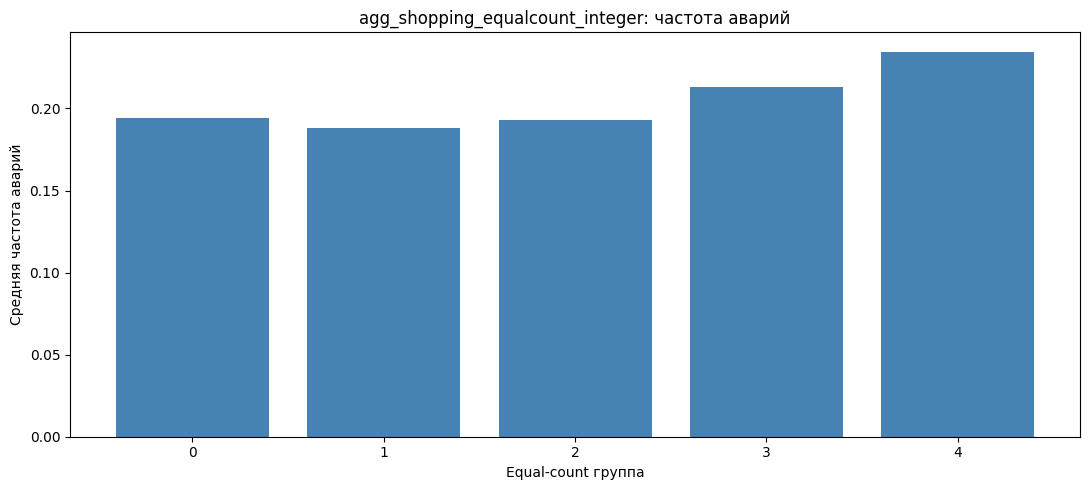


'shopping': {
    'TAG_20158': 10,
    'TAG_22019': 10,
    'TAG_12952': 9,
    'TAG_20937': 8,
    'TAG_20178': 8,
    'TAG_21998': 7,
    'TAG_21144': 5,
    'TAG_12610': 5,
    'TAG_27180': 4,
    'TAG_20144': 4,
    'TAG_20474': 3,
    'TAG_20043': 3,
    'TAG_20170': 3,
    'TAG_21194': 3,
    'TAG_22098': 3,
    'TAG_21162': 3,
    'TAG_22116': 3,
    'TAG_15897': 2,
    'TAG_15928': 2,
    'TAG_12608': 2,
    'TAG_15937': 2,
    'TAG_13509': 2,
    'TAG_21243': 2,
    'TAG_21177': 2,
    'TAG_12637': 2,
    'TAG_12668': 1,
    'TAG_12979': 1,
    'TAG_20194': 1,
    'TAG_20575': 1,
    'TAG_10907': 1,
    'TAG_27168': 1,
    'TAG_21066': 1,
    'TAG_12954': 1,
    'TAG_22112': 1,
    'TAG_20177': 1,
    'TAG_21138': 1,
    'TAG_12969': 1,
    'TAG_21130': 1,
    'TAG_12975': 1,
    'TAG_27183': 1,
}


In [19]:
# --- Пример: поиск комбинации TAG + groups с динамикой (strict equal-count) для shopping ---

new_features_monotonic_integer = new_features.copy()

y_group = casco_hashtags_full['BINARY_CLAIMS_PART_DAM_COUNT']

best_grouper_int, best_tags_int, search_df_int, ranked_weights_int = search_integer_equalcount_dynamic(
    df=casco_hashtags_full,
    feature_cols=shopping_features_list,
    y=y_group,
    candidate_groups=list(range(20, 31)),
    candidate_tag_counts=[8, 12, 16, 20, None],
    trend_mode='up_soft',  # мягко восходящий тренд
    C=0.35,
    max_int_weight=10,
    min_nonzero_weight=1,
    random_state=42,
    soft_min_up_share=0.70,
    soft_min_slope=0.0,
    verbose=False
)

if best_grouper_int is None:
    raise ValueError('Не удалось подобрать ни одной конфигурации')

groups_int, auto_score_int = best_grouper_int.transform(casco_hashtags_full)
new_features_monotonic_integer['agg_shopping_equalcount_integer'] = groups_int

print('Top-20 TAG по integer-весу (ранжирование):')
print(ranked_weights_int.head(20).to_string())

print()
print('Поиск конфигураций (top-20):')
print(search_df_int.head(20).to_string(index=False))

print()
print('Выбранная конфигурация:')
print(f"tag_count={len(best_tags_int)}")
print(f"requested_groups={best_grouper_int.n_groups_requested_}")
print(f"effective_groups={best_grouper_int.n_groups_effective_}")
print(f"actual_groups={best_grouper_int.n_groups_actual_}")
print(f"equal_group_size={best_grouper_int.equal_group_size_}")

check_df_monotonic_int = pd.concat([
    new_features_monotonic_integer[['agg_shopping_equalcount_integer']],
    y_group
], axis=1)

analysis_monotonic_int = (
    check_df_monotonic_int.groupby('agg_shopping_equalcount_integer', as_index=True)['BINARY_CLAIMS_PART_DAM_COUNT']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
    .sort_index()
)

print()
print('Анализ agg_shopping_equalcount_integer:')
print(analysis_monotonic_int)

objects_min = int(analysis_monotonic_int['objects'].min())
objects_max = int(analysis_monotonic_int['objects'].max())
objects_ratio = float(objects_max / objects_min) if objects_min > 0 else np.nan
print()
print(f"Размеры групп (min/max): {objects_min}/{objects_max}, ratio={objects_ratio:.3f}")
print(f"Строго одинаковые группы: {objects_min == objects_max}")

direction_int, mono_up_int, mono_down_int = _detect_monotonic_direction(analysis_monotonic_int['claim_rate'].values)
print(f"Направление тренда: {direction_int}")
print(f"Неубывающий={mono_up_int}, невозрастающий={mono_down_int}")

plt.figure(figsize=(11, 5))
plt.bar(analysis_monotonic_int.index.astype(str), analysis_monotonic_int['claim_rate'], color='steelblue')
plt.title('agg_shopping_equalcount_integer: частота аварий')
plt.ylabel('Средняя частота аварий')
plt.xlabel('Equal-count группа')
plt.tight_layout()
plt.show()

# Расшифровка TAG -> имя + integer weight (только выбранные TAG)
used_int = (
    best_grouper_int.weights_
    .rename('integer_weight')
    .reset_index()
    .rename(columns={'index': 'TAG'})
    .sort_values('integer_weight', ascending=False)
)
tag_map = tags_descriptions[['TAG', 'TAG_NAME fin SBS']].drop_duplicates()
used_int = used_int.merge(tag_map, on='TAG', how='left')

print()
GROUP_KEY = 'shopping'
weights_for_export = used_int[['TAG', 'integer_weight']].copy()
weights_for_export['integer_weight'] = weights_for_export['integer_weight'].astype(int)
weights_dict = dict(zip(weights_for_export['TAG'], weights_for_export['integer_weight']))

print(f"'{GROUP_KEY}': {{")
for tag, integer_weight in weights_dict.items():
    print(f"    '{tag}': {int(integer_weight)},")
print('}')

